In [1]:
import logging

import atlite

logging.basicConfig(level=logging.INFO)

import io
import os
import pathlib

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xarray as xr
from atlite.gis import ExclusionContainer, shape_availability
from shapely.geometry import Polygon
import fiona
from shapely.geometry import Polygon, box
from shapely.geometry import MultiPoint
from shapely.ops import voronoi_diagram

In [2]:
desired_regions_2024 = [
    "NO0A1", # Rogaland
    "NO0A2", # Vestland
    "NO0A3", # Møre og Romsdal
    "NO020", # Innlandet
    "NO060", # Trøndelag
    "NO071", # Nordland
    "NO072", # Troms
    "NO073", # Finnmark
    "NO081", # Oslo
    "NO083", # Østfold
    "NO084", # Akershus
    "NO085", # Buskerud
    "NO092", # Agder
    "NO093", # Vestfold
    "NO094", # Telemark
  ]

# Offshore

In [3]:
onshore_2024 = "/fp/homes01/u01/ec-javedm/ec85/models/shahzad/highRES-model/resources/new_counties/NUTS_RG_01M_2024_4326.geojson"

In [4]:
onshore = (
    gpd.read_file(onshore_2024) #, engine='fiona')
    .replace({"GB": "UK", "EL": "GR"})
    .query("NUTS_ID in @desired_regions_2024 ")
    .rename(columns={"NUTS_ID": "index"})
    .loc[:, ["index", "CNTR_CODE", "geometry"]]
    .set_index(["index"])
)

In [5]:
NO_onshore = onshore[onshore.index.str.contains("NO")]

In [6]:
rectNx1 = 4.1536268
rectNx2 = 33.2415665
rectNy1 = 57
rectNy2 = 72

In [7]:
polygon = Polygon(
    [
        (rectNx1, rectNy1),
        (rectNx1, rectNy2),
        (rectNx2, rectNy2),
        (rectNx2, rectNy1),
        (rectNx1, rectNy1),
    ]
)
NO_onshore = gpd.clip(NO_onshore, polygon)
#europe = gpd.clip(europe, box(rectx1, recty1, rectx2, 72))

<Axes: >

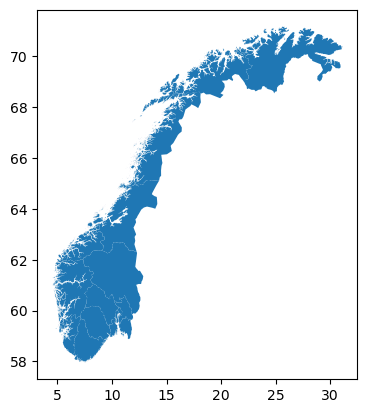

In [8]:
NO_onshore.plot()

In [9]:
NO_offshore_path= "/fp/projects01/ec85/shared_input/geodata/offshore/BOTTOM_MOUNTED_EUROPE_NUTS0" "_NORWAY_NUTS3.geojson"

In [10]:
norway_offshore = (gpd.read_file(NO_offshore_path).query("~NUTS_ID.isna() and NUTS_ID not in ['NO0B1', 'NO0B2']", engine="python") # remove Svalbard (NO0B2) and Jan Mayen (NO0B1)
    .dissolve()
    .assign(index="NO")
)
norway_offshore['geometry'] = norway_offshore['geometry'].difference(NO_onshore.dissolve()) 

norway_offshore

,geometry,index,OBJECTID_1,type,Shape_Leng,NUTS_ID,Shape_Le_1,Shape_Area
0,"MULTIPOLYGON (((3.27917 56.15833, 3.27774 56.1...",NO,72,3,0.0,NO060,3.321142,0.020517


In [11]:
centroids = NO_onshore.to_crs(3857).centroid.to_crs(NO_onshore.crs)
points = MultiPoint(list(centroids.geometry))
voronoi = voronoi_diagram(points)
norway_voronoi = gpd.GeoDataFrame(geometry=list(voronoi.geoms), crs=NO_onshore.crs)
norway_voronoi

,geometry
0,"POLYGON ((-13.44539 76.22816, 7.87247 61.14033..."
1,"POLYGON ((-13.44539 39.04508, -13.44539 62.358..."
2,"POLYGON ((1.06237 39.04508, 7.21716 59.92509, ..."
3,"POLYGON ((-13.44539 89.63563, -4.06930 89.6356..."
4,"POLYGON ((8.92923 61.83740, 9.99292 60.59559, ..."
5,"POLYGON ((9.99292 60.59559, 8.92923 61.83740, ..."
6,"POLYGON ((7.29094 59.96450, 7.75433 60.64721, ..."
7,"POLYGON ((11.01642 50.25599, 9.13484 57.95230,..."
8,"POLYGON ((13.01152 39.04508, 11.01642 50.25599..."
9,"POLYGON ((9.46833 63.22218, 6.59409 72.24961, ..."


In [12]:
shapes = []

for i in NO_onshore.index:
    point = NO_onshore.to_crs(3857).centroid.to_crs(NO_onshore.crs)[i]
    shapes.append(norway_voronoi[norway_voronoi.contains(point)].geometry.values[0])

norway_voronoi = gpd.GeoDataFrame({'index':NO_onshore.index, 'geometry':shapes}, crs=NO_onshore.crs).set_index('index')

In [13]:
offshore_counties = []
offshore_counties_index = []

for i in norway_voronoi.index:
    shape_array = norway_offshore.clip(norway_voronoi.loc[i].geometry).geometry.values
    if shape_array:
        offshore_counties.append(shape_array[0])
        offshore_counties_index.append(i)
norway_offshore = gpd.GeoDataFrame({'index':offshore_counties_index, 'geometry':offshore_counties}, crs=NO_onshore.crs)
norway_offshore = gpd.clip(norway_offshore, box(rectNx1, rectNy1, rectNx2, rectNy2)).set_index("index") # Remove Svalbard
norway_offshore

,geometry
index,
NO092,"MULTIPOLYGON (((6.41727 57.21147, 6.42701 57.2..."
NO0A1,"MULTIPOLYGON (((4.16474 57.36890, 4.17951 57.3..."
NO0A2,"MULTIPOLYGON (((4.45235 61.67640, 4.45732 61.6..."
NO0A3,"MULTIPOLYGON (((5.77500 62.62483, 5.77475 62.6..."
NO060,"MULTIPOLYGON (((10.45000 64.67500, 10.45417 64..."
NO071,"MULTIPOLYGON (((13.48242 68.75976, 13.48607 68..."
NO072,"MULTIPOLYGON (((16.69387 69.52280, 16.70481 69..."
NO073,"MULTIPOLYGON (((22.77407 70.96376, 22.76926 70..."


<Axes: >

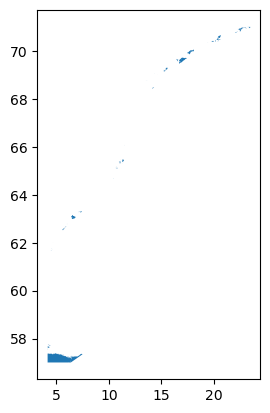

In [14]:
norway_offshore.plot()

In [15]:
norway_offshore.to_file("/fp/homes01/u01/ec-javedm/ec85/models/shahzad/highRES-model/resources/new_counties/norway_offshore_2024.geojson", driver="GeoJSON")

# offshore_floating

In [16]:
offshore_float_path= "/fp/projects01/ec85/shared_input/geodata/offshore/FLOATING_EUROPE_NUTS0_NORWAY_NUTS3.geojson"


In [18]:
norway_offshore_floating = (gpd.read_file(offshore_float_path)
                .query("~NUTS_ID.isna() and NUTS_ID not in ['NO0B1', 'NO0B2']", engine="python") # remove Svalbard (NO0B2) and Jan Mayen (NO0B1)
                .dissolve()
                .assign(index="NO")
)
#norway_offshore_floating['geometry'] = norway_offshore_floating['geometry'].difference(NO_onshore.dissolve()) 

norway_offshore_floating

,geometry,index,OBJECTID_1,type,Shape_Leng,NUTS_ID,Shape_Le_1,Shape_Area
0,"MULTIPOLYGON (((2.64233 56.57185, 2.62483 56.5...",NO,89,2,0.0,NO060,19.966888,10.320257


In [19]:
offshore_float_counties = []
offshore_float_counties_index = []

for i in norway_voronoi.index:
    shape_array = norway_offshore_floating.clip(norway_voronoi.loc[i].geometry).geometry.values
    if shape_array:
        offshore_float_counties.append(shape_array[0])
        offshore_float_counties_index.append(i)
norway_offshore_floating = gpd.GeoDataFrame({'index':offshore_float_counties_index, 'geometry':offshore_float_counties}, crs=NO_onshore.crs)
norway_offshore_floating = gpd.clip(norway_offshore_floating, box(rectNx1, rectNy1, rectNx2, rectNy2)).set_index("index") # Remove Svalbard
norway_offshore_floating

,geometry
index,
NO092,"MULTIPOLYGON (((6.65735 57.95723, 6.66961 57.9..."
NO094,"POLYGON ((8.84229 58.27828, 8.86206 58.28914, ..."
NO0A1,"MULTIPOLYGON (((5.10974 57.35033, 5.09798 57.3..."
NO093,"POLYGON ((9.21615 58.51674, 9.22395 58.52184, ..."
NO0A2,"MULTIPOLYGON (((4.16822 63.10685, 4.19583 63.1..."
NO0A3,"MULTIPOLYGON (((4.95200 63.23117, 4.99012 63.2..."
NO060,"MULTIPOLYGON (((8.22288 67.27296, 8.23546 67.2..."
NO071,"MULTIPOLYGON (((10.53490 68.25679, 10.55621 68..."
NO072,"MULTIPOLYGON (((16.41192 69.75759, 16.42713 69..."


<Axes: >

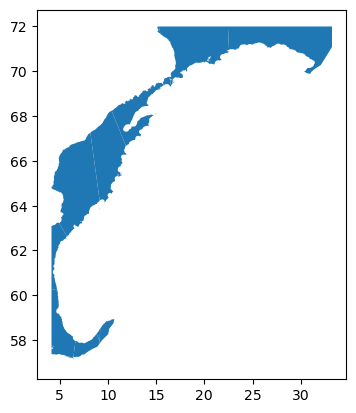

In [20]:
norway_offshore_floating.plot()

In [21]:
norway_offshore_floating.to_file("/fp/homes01/u01/ec-javedm/ec85/models/shahzad/highRES-model/resources/new_counties/norway_offshore_floating_2024.geojson", driver="GeoJSON")